In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
 #Moderne, aber wissenschaftlich saubere Einstellungen
plt.rcParams.update({
    # Moderne, saubere Schrift (ohne Schnörkel)
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    
    # Ticks zeigen nach außen und nur unten/links (viel offener)
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
    
    # Dezentes Gitter
    "axes.grid": True,
    "grid.color": "#7F8C8D",
    "grid.linestyle": ":",        # Gepunktet statt gestrichelt wirkt feiner
    "grid.alpha": 0.5,
    
    # Legende ohne Rahmen
    "legend.frameon": True,
    
    # Hohe Auflösung
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


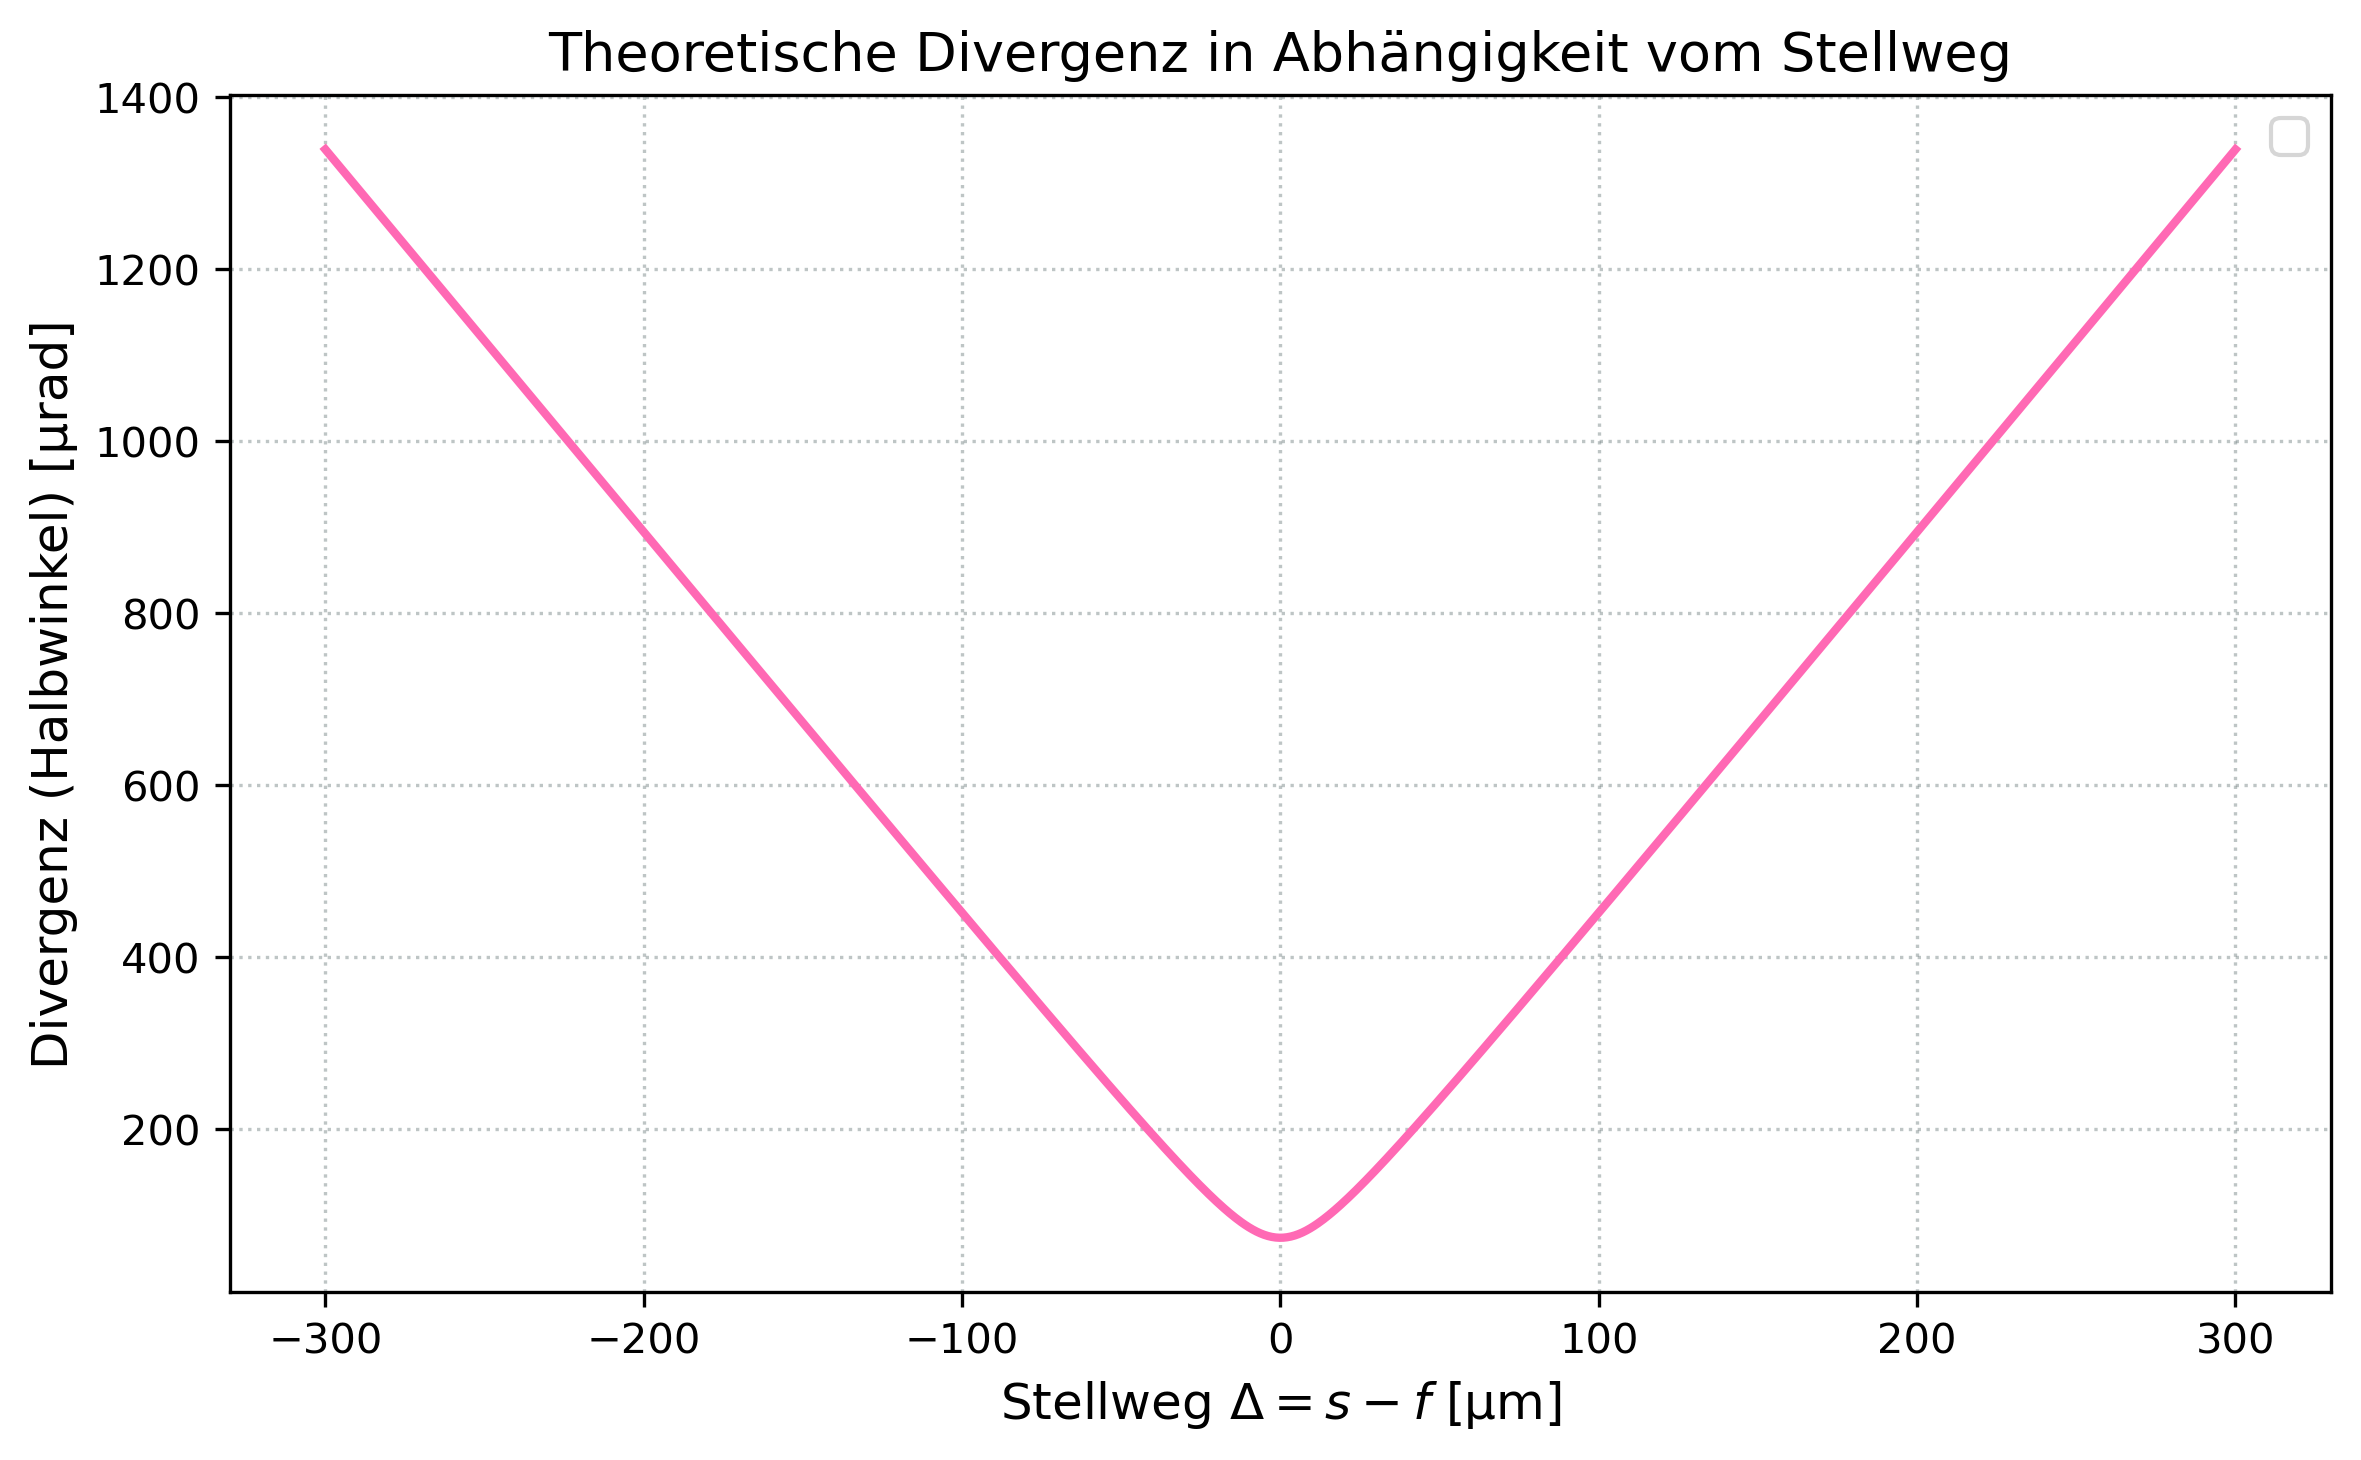

In [5]:
#erst nur stellweg
lam  = 1064e-9   # Wellenlänge [m]
M2   = 1.3       # Strahlqualitätsfaktor
MFD  = 5.4e-6    # Mode Field Diameter [m]
wf   = MFD / 2   # Waist-Radius am Faserende [m]
f    = 36.6e-3   # Brennweite [m]

lam_eff = M2 * lam  

# Das ist dein Stellweg um den perfekten Fokuspunkt (Delta)
delta = np.linspace(-300*1e-6, 300*1e-6, 1000)
zR = np.pi * wf**2 / lam_eff 

def winkel(delta_wert, brennweite, wf, lam_eff, zR):
    # 1. Den Bruch berechnen
    term1 = lam_eff / (np.pi * brennweite * wf)
    
    # 2. Delta direkt einsetzen (kein -f mehr nötig!)
    theta = np.sqrt(delta_wert**2 + zR**2) * term1
    
    return theta

# Berechnung durchführen
theta_winkel = winkel(delta, f, wf, lam_eff, zR)

plt.figure(figsize=(8, 5))
plt.plot(delta * 1e6, theta_winkel * 1e6, color='hotpink', linewidth=2)

plt.xlabel('Stellweg $\Delta =s-f$ [µm]')
plt.ylabel('Divergenz (Halbwinkel) [µrad]')
plt.title('Theoretische Divergenz in Abhängigkeit vom Stellweg')
#plt.axhspan(0, 1000, color='blue')
#plt.grid(True, linestyle=':', alpha=0.7)

# Eine kleine Markierung für das physikalische Minimum
#plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Perfekter Fokus')
plt.legend()

plt.tight_layout()
plt.show()

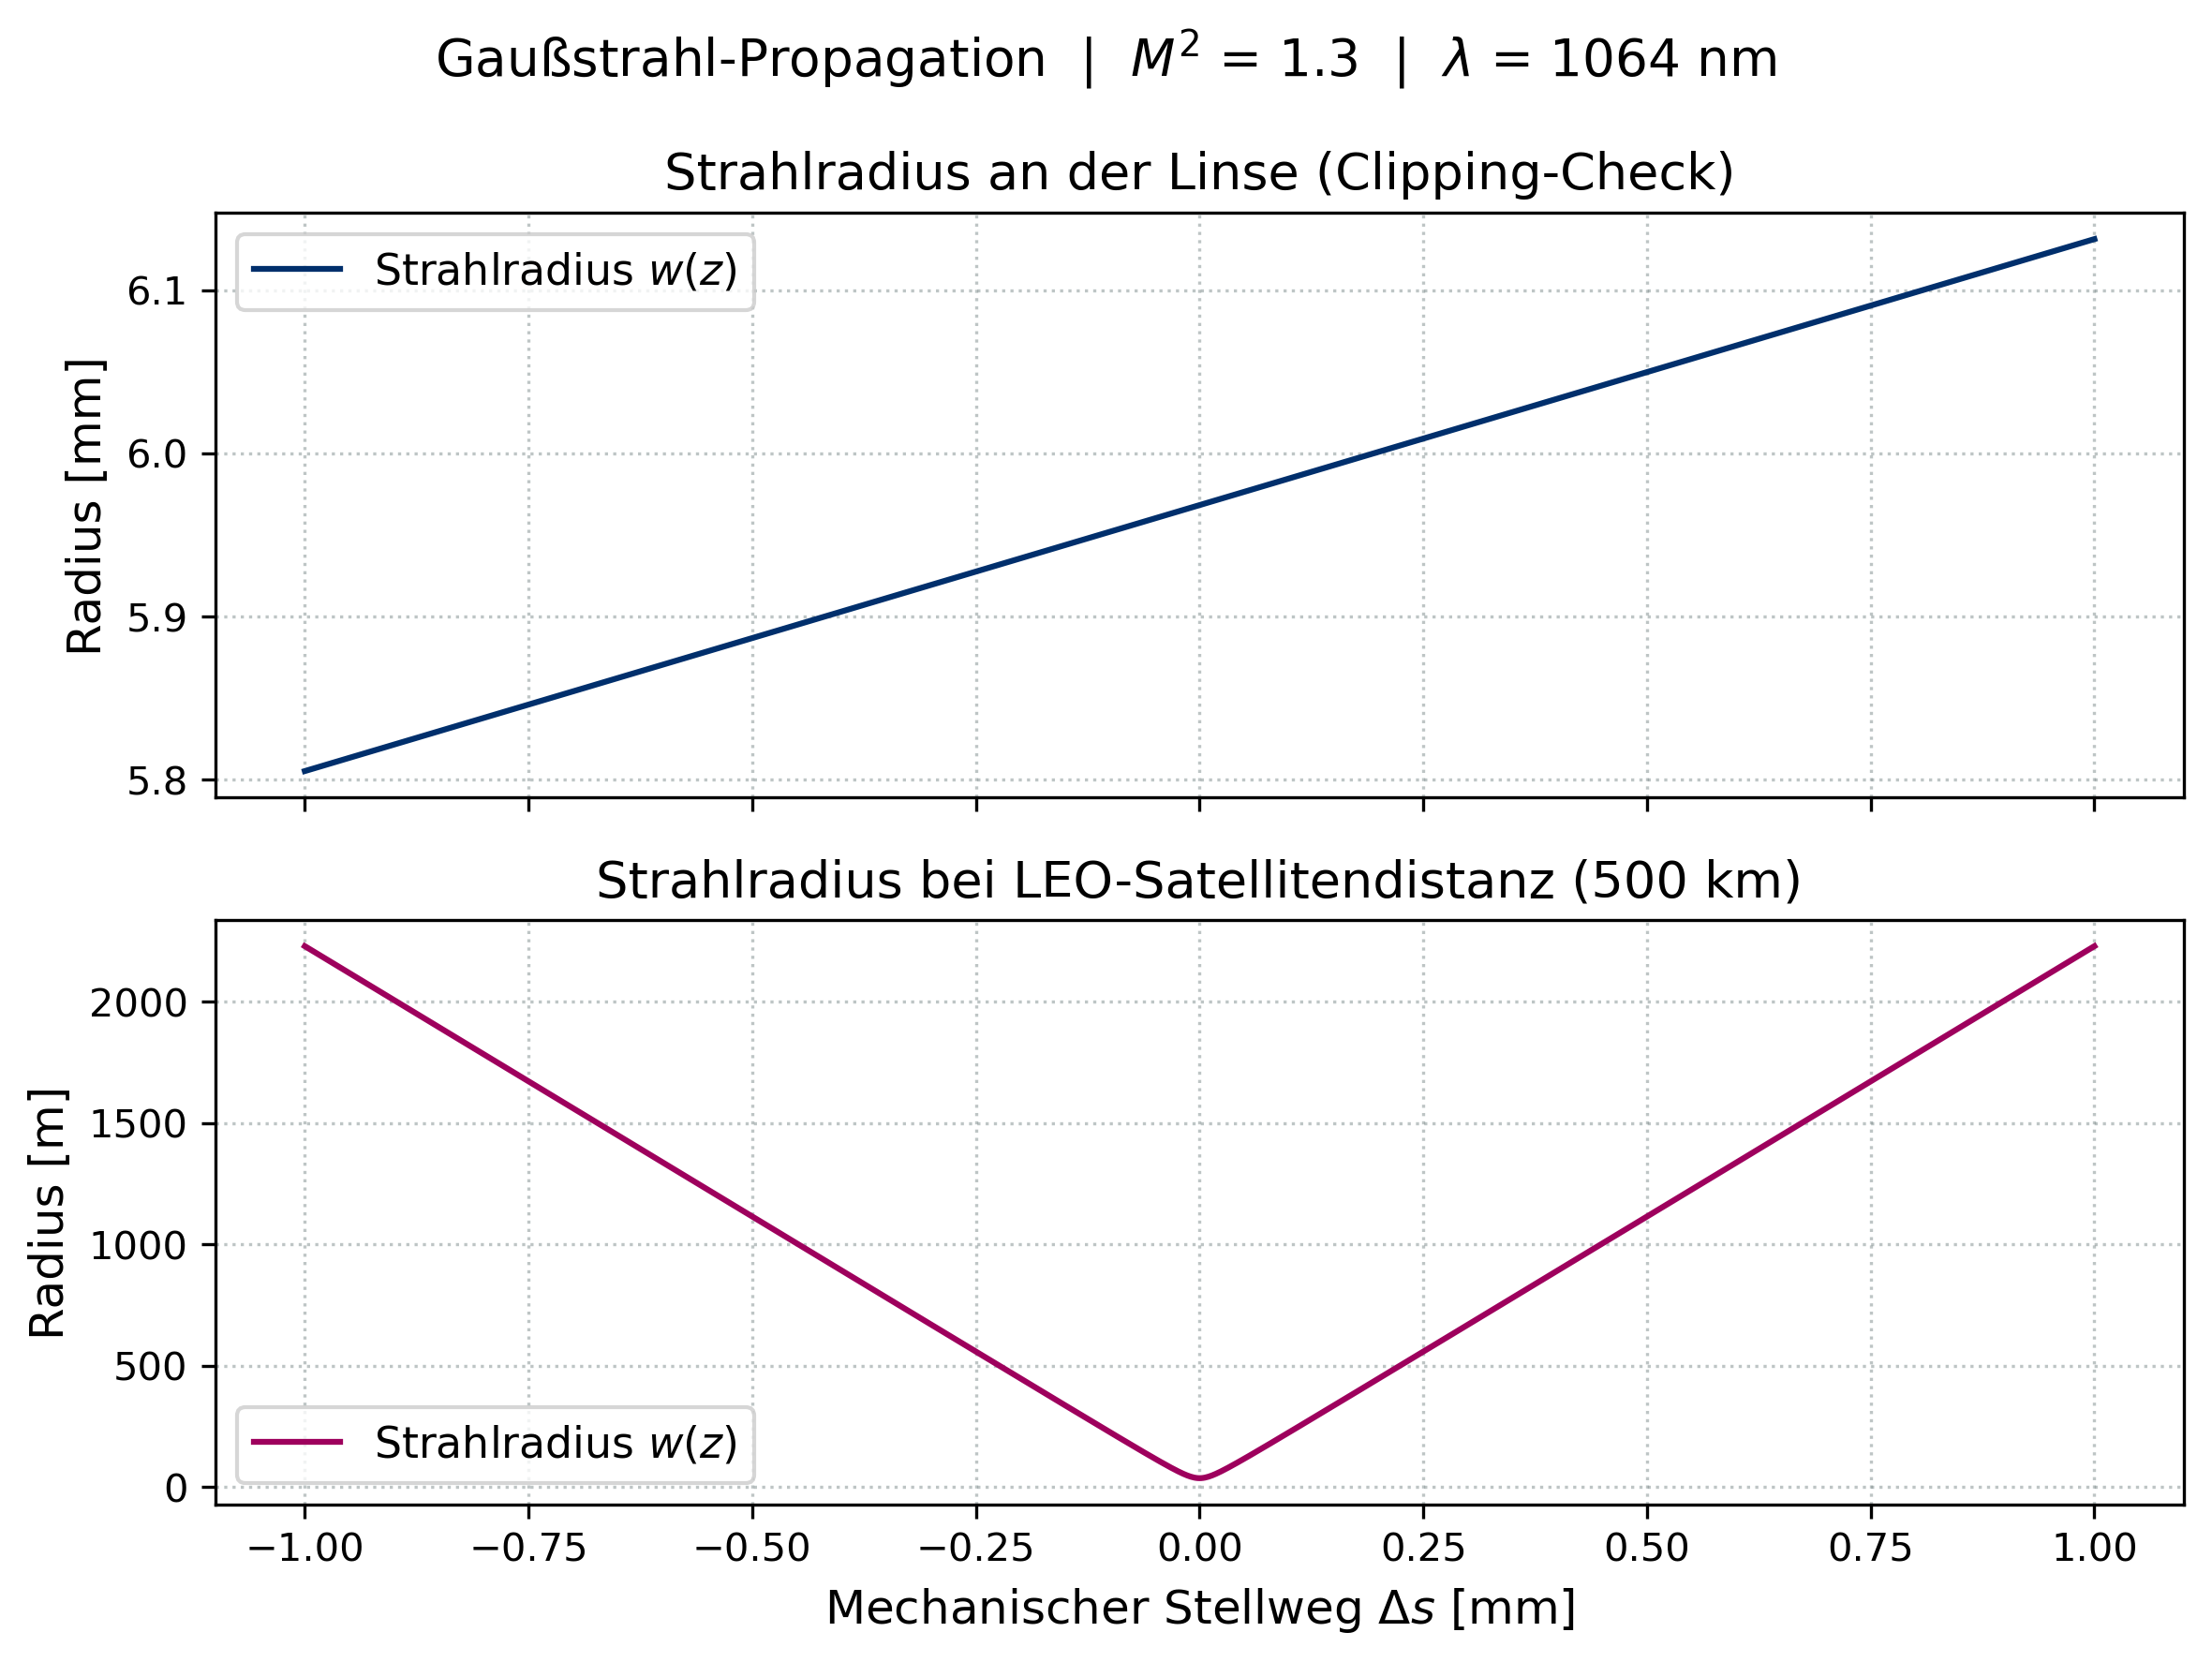

In [15]:
#andere plots von paul
# 
# 
# # ==========================================
# 1. Systemparameter
# ==========================================
lam = 1064e-9      # Wellenlänge [m]
f = 36.6e-3        # Brennweite Kollimator [m]
M2 = 1.3           # Strahlqualitätsfaktor
MFD = 5.4e-6       # Mode Field Diameter der Faser [m]
w0 = MFD / 2       # Strahltaillenradius an der Faser [m]

delta = np.linspace(-1e-3, 1e-3, 1001) # Mechanischer Stellweg [m]
s = f + delta      # Objektdistanz (Faser zu Linse) [m]

# ==========================================
# 2. Optische Berechnungen (Gaußstrahl)
# ==========================================
lam_eff = lam * M2                      # M^2 Korrektur
zR = (np.pi * w0**2) / lam_eff          # Rayleigh-Länge an der Faser [m]

# Strahlgröße an der Linse
w_lens = w0 * np.sqrt(1 + (s / zR)**2)  # Radius an der Linse [m]
d_lens = 2 * w_lens                     # Durchmesser an der Linse [m]

# q-Parameter Transformation
q1 = s + 1j * zR
q2 = 1 / (1 / q1 - 1 / f)

# Neue Taille nach der Linse
z_waist = -np.real(q2)                  # Position der neuen Taille (von Linse aus)
zR_neu = np.imag(q2)                    # Neue Rayleigh-Länge
w0_new = np.sqrt(zR_neu * lam_eff / np.pi) # Neuer Taillenradius

# Strahlgröße bei 500 km
z2 = 500e3                              # 500 km in [m]
w_500km = w0_new * np.sqrt(1 + ((z2 - z_waist) / zR_neu)**2)
d_500km = 2 * w_500km

# ==========================================
# 3. Plotting
# ==========================================
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
fig.suptitle(f"Gaußstrahl-Propagation  |  $M^2$ = {M2}  |  $\lambda$ = {lam*1e9:.0f} nm")#, fontsize=13, fontweight='bold'

# Plot 1: An der Linse
ax[0].plot(delta*1e3, w_lens*1e3, color='#002F6C', label="Strahlradius $w(z)$")
ax[0].set_ylabel("Radius [mm]")
ax[0].set_title("Strahlradius an der Linse (Clipping-Check)")
ax[0].legend()

# Plot 2: Bei 500 km
ax[1].plot(delta*1e3, w_500km, color='#9E005D', label="Strahlradius $w(z)$")
ax[1].set_xlabel("Mechanischer Stellweg $\Delta s$ [mm]")
ax[1].set_ylabel("Radius [m]")
ax[1].set_title("Strahlradius bei LEO-Satellitendistanz (500 km)")
ax[1].legend()
ax[1].legend()

plt.tight_layout()
plt.show()